In [85]:
import pandas as pd

df = pd.read_csv("Airline Passengers.csv")

df["Month"] = pd.to_datetime(df["Month"])

df = df.set_index("Month")

df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [86]:
df.tail()

,Passengers
Month,
1960-08-01,606
1960-09-01,508
1960-10-01,461
1960-11-01,390
1960-12-01,432


New information is based on previous information.

Text(0.5, 1.0, 'Airline Passengers Over Time')

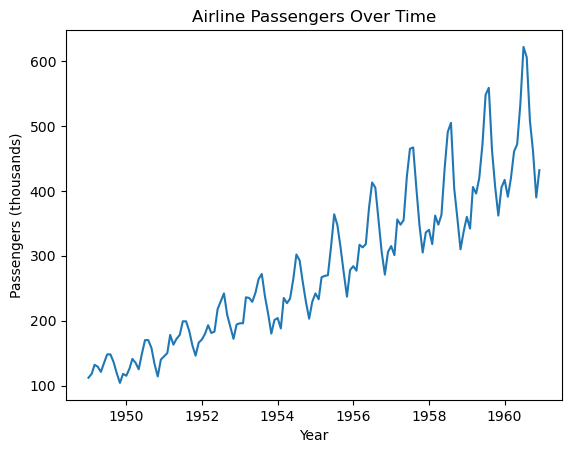

In [87]:
import matplotlib.pyplot as plt

plt.plot(df.index, df['Passengers'])
plt.xlabel('Year')
plt.ylabel('Passengers (thousands)')
plt.title('Airline Passengers Over Time')


The overall shape is a line that increases over time with consistent peaks and troughs.

Over the twelve years it looks like it is going up.

In [88]:
df['Rolling'] = df['Passengers'].rolling(window=12).mean()

Text(0.5, 1.0, 'Airline Passengers Over Time')

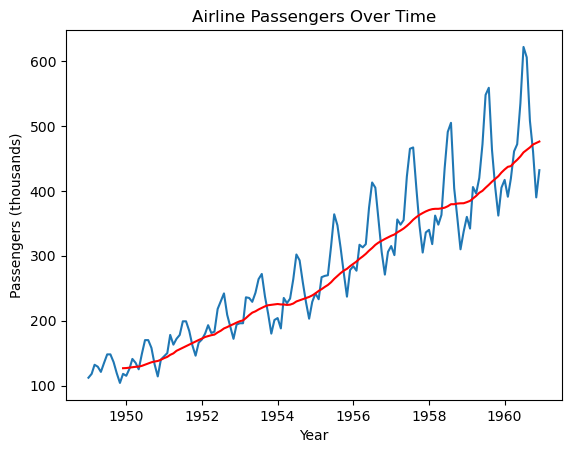

In [89]:
import matplotlib.pyplot as plt

plt.plot(df.index, df['Passengers'])
plt.plot(df.index, df['Rolling'], color='red')
plt.xlabel('Year')
plt.ylabel('Passengers (thousands)')
plt.title('Airline Passengers Over Time')

It does make the trend easier to see

([<matplotlib.axis.XTick at 0x162ce0a50>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12')])

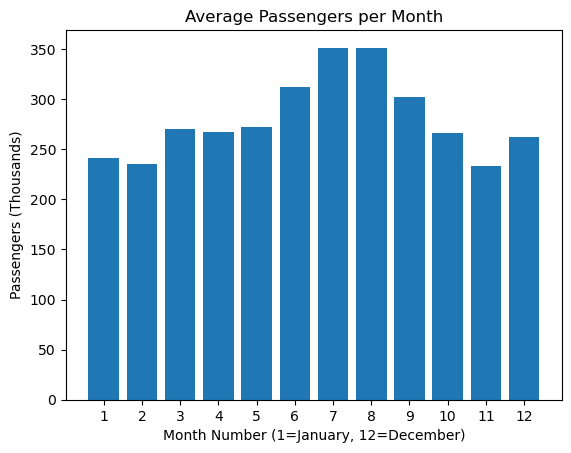

In [90]:
month_avg = df.groupby(df.index.month)['Passengers'].mean()
plt.bar(month_avg.index, month_avg.values)
plt.xlabel('Month Number (1=January, 12=December)')
plt.ylabel('Passengers (Thousands)')
plt.title('Average Passengers per Month')
plt.xticks(ticks=range(1,13))

July and August have the most, February and November have the least.

Summer break is around July/August and families might go on vacation a lot. February doesn't have any major holidays, and people might not travel a lot in November to save their PTO for Christmas/New Years

In [91]:
from prophet import Prophet

prophet_df = df.reset_index().rename(columns={"Month": "ds", "Passengers": "y"})


In [92]:
prophet_df = prophet_df.drop(columns="Rolling")

In [93]:
prophet_df.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


10:33:40 - cmdstanpy - INFO - Chain [1] start processing


10:33:40 - cmdstanpy - INFO - Chain [1] done processing


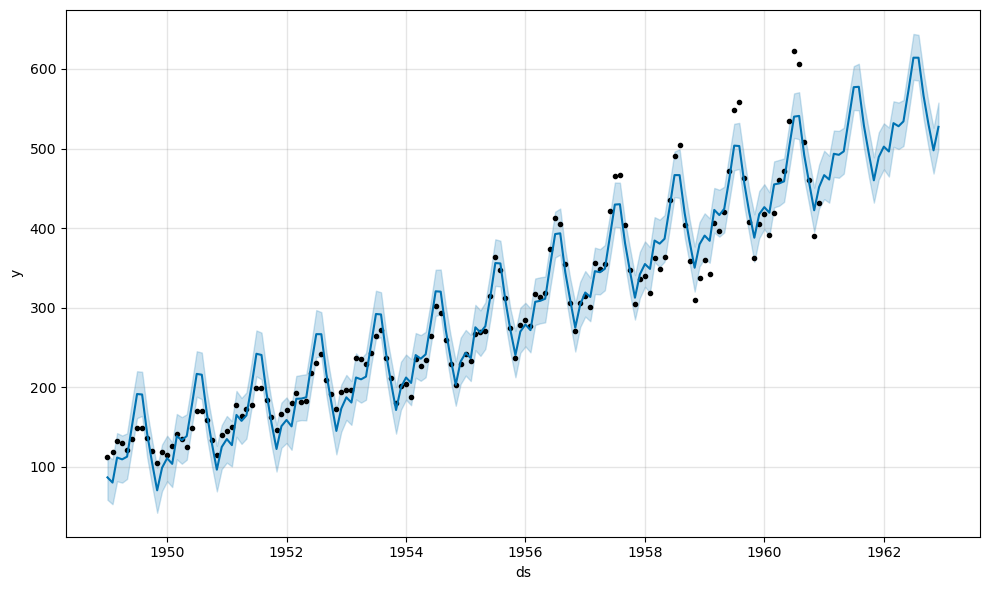

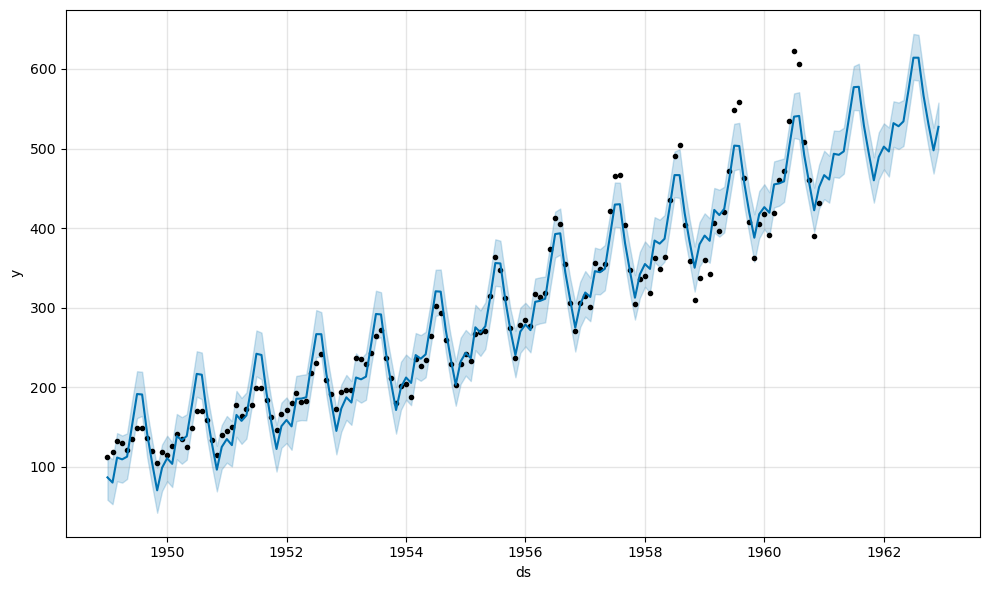

In [94]:
model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=24, freq="MS")

forecast = model.predict(future)

model.plot(forecast)

It stays the same.

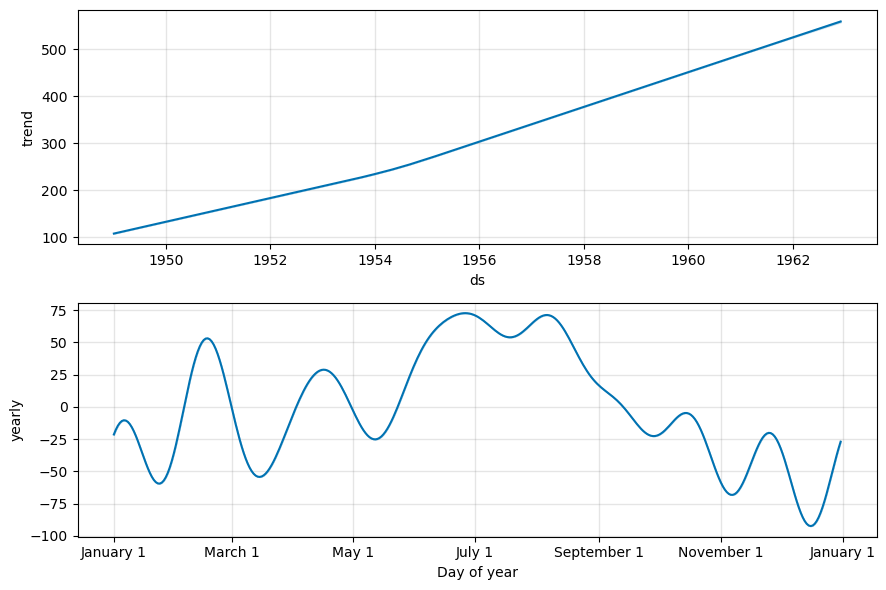

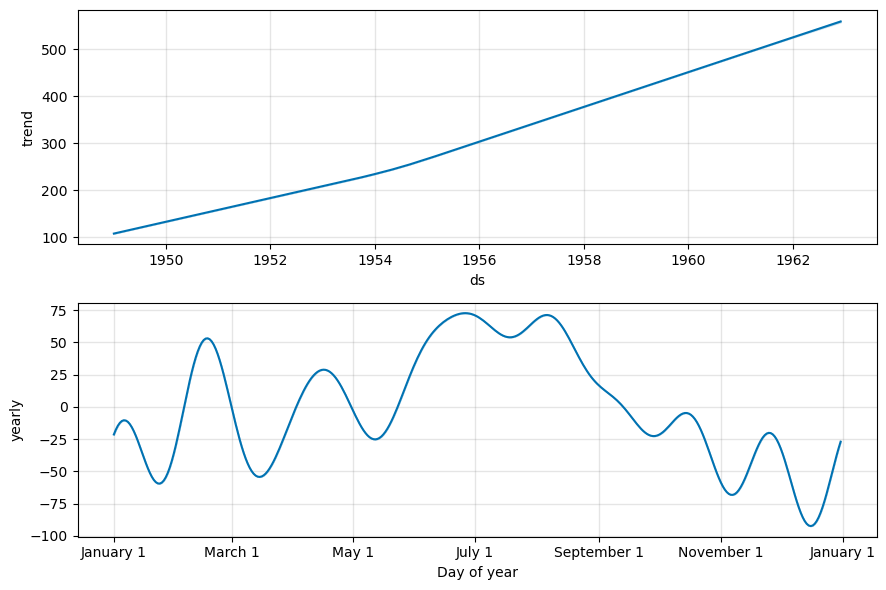

In [95]:
model.plot_components(forecast)

Both charts agree with the rolling mean charts.

In [96]:
train = prophet_df.iloc[:-12]
test = prophet_df.iloc[-12:]

model = Prophet()
model.fit(train)

future = model.make_future_dataframe(periods=12, freq="MS")
forecast = model.predict(future)

comparison = test.merge(forecast[["ds", "yhat"]], on="ds")

mae = (comparison["y"] - comparison["yhat"]).abs().mean() 
print("MAE:", mae)

10:33:41 - cmdstanpy - INFO - Chain [1] start processing
10:33:41 - cmdstanpy - INFO - Chain [1] done processing


MAE: 33.43694737330078


This is data leakage because you are the rows were randomly shuffled. This means that future data that you are "testing" on would be exposed to the model, giving it a better idea of what it should predict at those values. A chronological split avoids this problem because you give the model one time period of data, and test it on a completely different time period of data, so all points you are trying to predict are separate from the ones you train the model on. This avoids data leakage and yields a more pure, predictive model.

In [97]:
def forecast_eval(df, months):
    df = df.sort_values('ds').reset_index(drop=True)
    model = Prophet()
    train = df.iloc[:-months]
    test = df.iloc[-months:]
    model.fit(train)
    future = model.make_future_dataframe(months, freq='MS')
    forecast = model.predict(future)
    comparison = test.merge(forecast[["ds", "yhat"]], on="ds")
    mae = (comparison["y"] - comparison["yhat"]).abs().mean() 
    return mae, forecast, model
    

In [98]:
df['y'] = df['Passengers']
df['ds'] = df.index
df = df[['ds', 'y']]
df.reset_index(drop=True)

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [99]:
mae, forecast, model = forecast_eval(df, 12)

10:33:41 - cmdstanpy - INFO - Chain [1] start processing


10:33:41 - cmdstanpy - INFO - Chain [1] done processing


In [100]:
print(mae)

33.43694737330078


In [101]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1949-01-01,109.171291,59.371582,112.350261,109.171291,109.171291,-23.936987,-23.936987,-23.936987,-23.936987,-23.936987,-23.936987,0.0,0.0,0.0,85.234304
1,1949-02-01,111.324338,52.710660,103.218514,111.324338,111.324338,-32.461724,-32.461724,-32.461724,-32.461724,-32.461724,-32.461724,0.0,0.0,0.0,78.862614
2,1949-03-01,113.269026,89.511218,141.540687,113.269026,113.269026,3.278420,3.278420,3.278420,3.278420,3.278420,3.278420,0.0,0.0,0.0,116.547446
3,1949-04-01,115.422073,82.483640,134.491236,115.422073,115.422073,-6.105212,-6.105212,-6.105212,-6.105212,-6.105212,-6.105212,0.0,0.0,0.0,109.316861
4,1949-05-01,117.505667,87.914083,138.434259,117.505667,117.505667,-5.268909,-5.268909,-5.268909,-5.268909,-5.268909,-5.268909,0.0,0.0,0.0,112.236758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,1960-08-01,467.922611,500.086598,552.440130,467.645903,468.213527,59.350488,59.350488,59.350488,59.350488,59.350488,59.350488,0.0,0.0,0.0,527.273100
140,1960-09-01,470.940923,459.817193,511.187245,470.603910,471.292509,15.105942,15.105942,15.105942,15.105942,15.105942,15.105942,0.0,0.0,0.0,486.046866
141,1960-10-01,473.861870,426.150539,479.629625,473.447869,474.270515,-21.496586,-21.496586,-21.496586,-21.496586,-21.496586,-21.496586,0.0,0.0,0.0,452.365284
142,1960-11-01,476.880182,397.504705,447.456135,476.404132,477.351306,-54.341258,-54.341258,-54.341258,-54.341258,-54.341258,-54.341258,0.0,0.0,0.0,422.538924


In [102]:
model